# parametre değişimi sonuçlarının tutlacağı dosya için

In [ ]:
from google.colab import files
uploaded = files.upload()

import pandas as pd
# Use the actual uploaded filename from the 'uploaded' dictionary
log = pd.read_csv(list(uploaded.keys())[0])
log

Saving experiment_log_lstm (1).csv to experiment_log_lstm (1).csv


,epoch,embedding_dim,hidden_dim,num_layers,bidirectional,lr,batch_size,max_len,test_loss,precision,recall,f1,accuracy,weight_decay,dropout
0,8,64,64,3,True,0.0010,128,100,0.728605,0.703455,0.659763,0.674966,0.659763,0.000001,0.3
1,20,64,64,2,True,0.0010,128,200,0.611014,0.718665,0.674504,0.689312,0.674504,0.000001,0.3
2,20,64,64,2,True,0.0001,128,200,0.611014,0.718665,0.674504,0.689312,0.674504,0.000001,0.3
3,15,64,64,2,True,0.0001,128,200,0.599988,0.741429,0.683495,0.700076,0.683495,0.000001,0.3


In [ ]:
LOG_FILE = "experiment_log_lstm.csv"


In [ ]:
import os
import pandas as pd

# Eğer dosya yoksa başlık satırı oluştursun
if not os.path.exists(LOG_FILE):
    pd.DataFrame(columns=["epoch",
        "embedding_dim", "hidden_dim", "num_layers", "bidirectional",
        "lr", "batch_size", "max_len",
        "test_loss", "precision", "recall", "f1", "accuracy","weight_decay"
    ]).to_csv(LOG_FILE, index=False)


# Kurulum + IMDb spoiler verisini çek

In [ ]:
!pip install scikit-learn kaggle -q

from google.colab import files
files.upload()  # kaggle.json'ı seç

!mkdir -p ~/.kaggle
!mv kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

!kaggle datasets download -d rmisra/imdb-spoiler-dataset -q
!unzip -n imdb-spoiler-dataset.zip -d data > /dev/null

import pandas as pd

df = pd.read_json("data/IMDB_reviews.json", lines=True)
print(df.head())
print(df.columns)


Saving kaggle.json to kaggle.json
Dataset URL: https://www.kaggle.com/datasets/rmisra/imdb-spoiler-dataset
License(s): Attribution 4.0 International (CC BY 4.0)
        review_date   movie_id    user_id  is_spoiler  \
0  10 February 2006  tt0111161  ur1898687        True   
1  6 September 2000  tt0111161  ur0842118        True   
2     3 August 2001  tt0111161  ur1285640        True   
3  1 September 2002  tt0111161  ur1003471        True   
4       20 May 2004  tt0111161  ur0226855        True   

                                         review_text  rating  \
0  In its Oscar year, Shawshank Redemption (writt...      10   
1  The Shawshank Redemption is without a doubt on...      10   
2  I believe that this film is the best story eve...       8   
3  **Yes, there are SPOILERS here**This film has ...      10   
4  At the heart of this extraordinary movie is a ...       8   

                                  review_summary  
0  A classic piece of unforgettable film-making.  
1     Sim

# Sadece text ve label kolonlarını hazırla + split

In [ ]:
# review_text -> text, is_spoiler -> label
df = df.rename(columns={
    "review_text": "text",
    "is_spoiler": "label"
})

df["text"] = df["text"].astype(str)
df["label"] = df["label"].astype(int)

print(df[["text", "label"]].head())
print(df["label"].value_counts())

from sklearn.model_selection import train_test_split

df_train, df_temp = train_test_split(
    df,
    test_size=0.3,
    random_state=42,
    stratify=df["label"]
)

df_val, df_test = train_test_split(
    df_temp,
    test_size=0.5,
    random_state=42,
    stratify=df_temp["label"]
)

print("Train:", len(df_train), "Val:", len(df_val), "Test:", len(df_test))


                                                text  label
0  In its Oscar year, Shawshank Redemption (writt...      1
1  The Shawshank Redemption is without a doubt on...      1
2  I believe that this film is the best story eve...      1
3  **Yes, there are SPOILERS here**This film has ...      1
4  At the heart of this extraordinary movie is a ...      1
label
0    422989
1    150924
Name: count, dtype: int64
Train: 401739 Val: 86087 Test: 86087


# Vocab + Dataset + DataLoader

In [ ]:
from collections import Counter
import re
import torch
from torch.utils.data import Dataset, DataLoader

MAX_LEN = 500
MIN_FREQ = 2
PAD_IDX = 0
UNK_IDX = 1

def basic_tokenize(text):
    text = text.lower()
    text = re.sub(r"[^a-z0-9çğıöşüâêîôû ]+", " ", text)
    return text.split()

# ---- VOCAB sadece train'den ----
counter = Counter()
for t in df_train["text"]:
    counter.update(basic_tokenize(t))

itos = ["<pad>", "<unk>"]
for tok, freq in counter.items():
    if freq >= MIN_FREQ:
        itos.append(tok)

stoi = {tok: i for i, tok in enumerate(itos)}
vocab_size = len(itos)
print("vocab_size =", vocab_size)

def encode_text(text):
    tokens = basic_tokenize(text)
    ids = [stoi.get(tok, UNK_IDX) for tok in tokens]
    if len(ids) < MAX_LEN:
        ids = ids + [PAD_IDX] * (MAX_LEN - len(ids))
    else:
        ids = ids[:MAX_LEN]
    return ids

class SpoilerDataset(Dataset):
    def __init__(self, df):
        self.texts = df["text"].tolist()
        self.labels = df["label"].tolist()
    def __len__(self):
        return len(self.texts)
    def __getitem__(self, idx):
        x = torch.tensor(encode_text(self.texts[idx]), dtype=torch.long)
        y = torch.tensor(self.labels[idx], dtype=torch.long)
        return x, y

BATCH_SIZE = 128
train_loader = DataLoader(SpoilerDataset(df_train), batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(SpoilerDataset(df_val),   batch_size=BATCH_SIZE)
test_loader  = DataLoader(SpoilerDataset(df_test),  batch_size=BATCH_SIZE)


vocab_size = 121911


# LSTM modeli

In [ ]:
import torch.nn as nn
dropout=0.5
class LSTMSpoilerClassifier(nn.Module):
    def __init__(self, vocab_size, embed_dim=128, hidden_dim=128,
                 num_layers=1, bidirectional=True, num_classes=2, pad_idx=PAD_IDX):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=pad_idx)
        self.lstm = nn.LSTM(
            input_size=embed_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            bidirectional=bidirectional
        )
        factor = 2 if bidirectional else 1
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_dim * factor, num_classes)

    def forward(self, x):
        emb = self.embedding(x)
        out, (h_n, c_n) = self.lstm(emb)

        if self.lstm.bidirectional:
            h_forward = h_n[-2, :, :]
            h_backward = h_n[-1, :, :]
            h = torch.cat((h_forward, h_backward), dim=1)
        else:
            h = h_n[-1, :, :]

        h = self.dropout(h)
        logits = self.fc(h)
        return logits

embedding_dimm = 64
hidden_dimm = 64
num_layersm = 2
bidirectional = True


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = LSTMSpoilerClassifier(
    vocab_size=vocab_size,
    embed_dim=embedding_dimm,
    hidden_dim=hidden_dimm,
    num_layers=num_layersm,
    bidirectional=bidirectional,
    pad_idx=PAD_IDX).to(device)

model


LSTMSpoilerClassifier(
  (embedding): Embedding(121911, 64, padding_idx=0)
  (lstm): LSTM(64, 64, num_layers=2, batch_first=True, bidirectional=True)
  (dropout): Dropout(p=0.5, inplace=False)
  (fc): Linear(in_features=128, out_features=2, bias=True)
)

# Loss, optimizer, train/eval fonksiyonları

In [ ]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np
from sklearn.metrics import f1_score, accuracy_score
from tqdm import tqdm

from tqdm import tqdm
from sklearn.metrics import f1_score, accuracy_score
import torch
y_train = df_train["label"].values
class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.array([0,1]),
    y=y_train
)
class_weights = torch.tensor(class_weights, dtype=torch.float).to(device)

criterion = nn.CrossEntropyLoss(weight=class_weights)
weight_dec=1e-6
optimizer = torch.optim.Adam(
    model.parameters(),
    lr=1e-4,
    weight_decay=weight_dec    # ←Weight Decay (L2 regularization)
)




def train_one_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss = 0
    all_preds, all_labels = [], []

    pbar = tqdm(loader, desc="Training", leave=False)

    for x, y in pbar:
        x = x.to(device)
        y = y.to(device)

        optimizer.zero_grad()
        logits = model(x)
        loss = criterion(logits, y)
        loss.backward()

        # ---- GRADIENT CLIPPING EKLENDİ ----
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)

        optimizer.step()

        total_loss += loss.item() * x.size(0)

        preds = logits.argmax(dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(y.cpu().numpy())

        pbar.set_postfix({"loss": loss.item()})

    avg_loss = total_loss / len(loader.dataset)
    f1 = f1_score(all_labels, all_preds, average="weighted")
    acc = accuracy_score(all_labels, all_preds)
    return avg_loss, f1, acc


def evaluate_with_metrics(model, loader, criterion):
    model.eval()
    total_loss = 0
    all_preds, all_labels = [], []

    with torch.no_grad():
        for x, y in loader:
            x = x.to(device)
            y = y.to(device)
            logits = model(x)
            loss = criterion(logits, y)

            total_loss += loss.item() * x.size(0)
            preds = logits.argmax(dim=1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(y.cpu().numpy())

    avg_loss = total_loss / len(loader.dataset)

    precision = precision_score(all_labels, all_preds, average="weighted", zero_division=0)
    recall    = recall_score(all_labels, all_preds, average="weighted", zero_division=0)
    f1        = f1_score(all_labels, all_preds, average="weighted")
    accuracy  = accuracy_score(all_labels, all_preds)

    return avg_loss, precision, recall, f1, accuracy


In [ ]:
def log_experiment(epoch,embedding_dim, hidden_dim, num_layers, bidirectional,
                   lr, batch_size, max_len,
                   test_loss, precision, recall, f1, accuracy,weight_decay,dropout):

    new_row = pd.DataFrame([{
        "epoch": epoch,
        "embedding_dim": embedding_dim,
        "hidden_dim": hidden_dim,
        "num_layers": num_layers,
        "bidirectional": bidirectional,
        "lr": lr,
        "batch_size": batch_size,
        "max_len": max_len,
        "test_loss": test_loss,
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "accuracy": accuracy,
        "weight_decay": weight_dec,
        "dropout":dropout}])

    new_row.to_csv(LOG_FILE, mode='a', header=False, index=False)
    print("✔ Deney kaydedildi:", LOG_FILE)


# Eğit

In [ ]:
import copy

train_loss_list = []
val_loss_list = []
train_f1_list = []
val_f1_list   = []

EPOCHS = 30           # maximum epoch
patience = 10          # iyileşme yoksa kaç epoch bekleyeceğiz
best_val_f1 = 0.0
best_epoch = 0
patience_counter = 0

best_model_state = copy.deepcopy(model.state_dict())

for epoch in range(1, EPOCHS + 1):
    print(f"\nEpoch {epoch}/{EPOCHS}")

    # ---- TRAIN ----
    train_loss, train_f1, train_acc = train_one_epoch(
        model, train_loader, optimizer, criterion
    )

    # ---- VALIDATION ----
    val_loss, val_precision, val_recall, val_f1, val_acc = evaluate_with_metrics(
        model, val_loader, criterion
    )

    train_loss_list.append(train_loss)
    val_loss_list.append(val_loss)

     # ---- F1 leri de kaydet ----
    train_f1_list.append(train_f1)
    val_f1_list.append(val_f1)

    print(f"  Train loss={train_loss:.4f}, f1={train_f1:.4f}, acc={train_acc:.4f}")
    print(f"  Val   loss={val_loss:.4f}, f1={val_f1:.4f}, acc={val_acc:.4f}")

    # ---- EARLY STOPPING (val F1'e göre) ----
    if val_f1 > best_val_f1 + 1e-4:
        best_val_f1 = val_f1
        best_epoch = epoch
        best_model_state = copy.deepcopy(model.state_dict())
        patience_counter = 0
        print("✅ Validation F1 iyileşti, en iyi modeli güncelledim.")
    else:
        patience_counter += 1
        print(f"⚠️ İyileşme yok, patience = {patience_counter}/{patience}")
        if patience_counter >= patience:
            print("⛔ Early stopping tetiklendi, eğitimi durduruyorum.")
            break

# ---- EN İYİ MODELİ GERİ YÜKLE ----
model.load_state_dict(best_model_state)
print(f"\nBest Validation F1: {best_val_f1:.4f} (Epoch {best_epoch})")



Epoch 1/30


  Train loss=0.6760, f1=0.6630, acc=0.6599
  Val   loss=0.6543, f1=0.6520, acc=0.6313
✅ Validation F1 iyileşti, en iyi modeli güncelledim.

Epoch 2/30


  Train loss=0.6564, f1=0.6708, acc=0.6581
  Val   loss=0.6422, f1=0.6990, acc=0.6916
✅ Validation F1 iyileşti, en iyi modeli güncelledim.

Epoch 3/30


  Train loss=0.6372, f1=0.6763, acc=0.6603
  Val   loss=0.6367, f1=0.6548, acc=0.6337
⚠️ İyileşme yok, patience = 1/10

Epoch 4/30


  Train loss=0.6304, f1=0.6740, acc=0.6564
  Val   loss=0.6253, f1=0.6778, acc=0.6609
⚠️ İyileşme yok, patience = 2/10

Epoch 5/30


...

  Train loss=0.5563, f1=0.7297, acc=0.7156
  Val   loss=0.5707, f1=0.7078, acc=0.6910
⚠️ İyileşme yok, patience = 4/10

Epoch 27/30


  Train loss=0.5537, f1=0.7299, acc=0.7154
  Val   loss=0.5717, f1=0.7257, acc=0.7132
⚠️ İyileşme yok, patience = 5/10

Epoch 28/30


  Train loss=0.5492, f1=0.7338, acc=0.7199
  Val   loss=0.5682, f1=0.7092, acc=0.6925
⚠️ İyileşme yok, patience = 6/10

Epoch 29/30


  Train loss=0.5465, f1=0.7360, acc=0.7224
  Val   loss=0.5757, f1=0.7281, acc=0.7163
⚠️ İyileşme yok, patience = 7/10

Epoch 30/30


  Train loss=0.5455, f1=0.7355, acc=0.7218
  Val   loss=0.5698, f1=0.7164, acc=0.7010
⚠️ İyileşme yok, patience = 8/10

Best Validation F1: 0.7437 (Epoch 22)


# Test sonucu (rapor için)

f1 learning curve

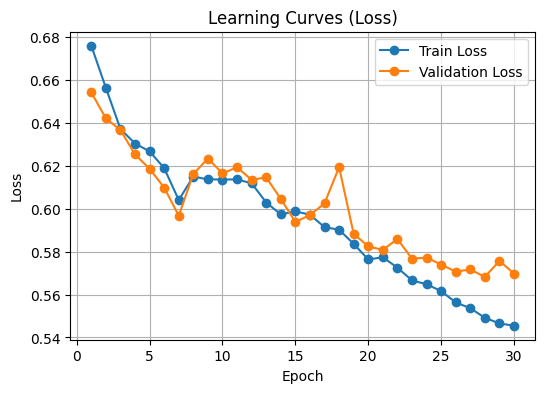

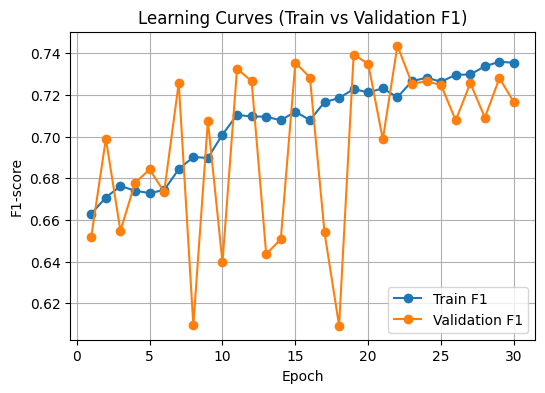

<Figure size 640x480 with 0 Axes>

In [ ]:
import matplotlib.pyplot as plt

# Zaten loss grafiğini çizmiştin, onun aynısı kalabilir
plt.figure(figsize=(6,4))
plt.plot(range(1, len(train_loss_list)+1), train_loss_list, label="Train Loss", marker="o")
plt.plot(range(1, len(val_loss_list)+1),   val_loss_list,   label="Validation Loss", marker="o")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Learning Curves (Loss)")
plt.legend()
plt.grid()
plt.show()

# ---- YENİ: F1 Learning Curve ----
plt.figure(figsize=(6,4))
plt.plot(range(1, len(train_f1_list)+1), train_f1_list, label="Train F1", marker="o")
plt.plot(range(1, len(val_f1_list)+1),   val_f1_list,   label="Validation F1", marker="o")
plt.xlabel("Epoch")
plt.ylabel("F1-score")
plt.title("Learning Curves (Train vs Validation F1)")
plt.legend()
plt.grid()
plt.show()
plt.savefig("learning_curve_f1.png", dpi=300, bbox_inches="tight")


In [ ]:
plt.savefig("learning_curve_f1_300.png", dpi=300, bbox_inches="tight")


<Figure size 640x480 with 0 Axes>

In [ ]:
from google.colab import files
files.download("learning_curve_f1_300.png")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import os
import pandas as pd

# Eğer dosya yoksa başlık satırı oluştursun
if not os.path.exists(LOG_FILE):
    pd.DataFrame(columns=["epoch",
        "embedding_dim", "hidden_dim", "num_layers", "bidirectional",
        "lr", "batch_size", "max_len",
        "test_loss", "precision", "recall", "f1", "accuracy","weight_dec"
    ]).to_csv(LOG_FILE, index=False)


In [ ]:
test_loss, test_precision, test_recall, test_f1, test_accuracy = evaluate_with_metrics(
    model, test_loader, criterion
)

print("---- TEST RESULTS ----")
print(f"Loss:      {test_loss:.4f}")
print(f"Precision: {test_precision:.4f}")
print(f"Recall:    {test_recall:.4f}")
print(f"F1-score:  {test_f1:.4f}")
print(f"Accuracy:  {test_accuracy:.4f}")

log_experiment(
    epoch=best_epoch,
    embedding_dim=embedding_dimm,          # burada kullandığın değerleri yaz
    hidden_dim=hidden_dimm,
    num_layers=num_layersm,
    bidirectional=True,
    lr=1e-4,
    batch_size=BATCH_SIZE,
    max_len=MAX_LEN,
    test_loss=test_loss,
    precision=test_precision,
    recall=test_recall,
    f1=test_f1,
    accuracy=test_accuracy,
    weight_decay=weight_dec,
    dropout=dropout
)



---- TEST RESULTS ----
Loss:      0.5893
Precision: 0.7453
Recall:    0.7396
F1-score:  0.7422
Accuracy:  0.7396
✔ Deney kaydedildi: experiment_log_lstm.csv


In [ ]:
import torch
import torch.nn.functional as F
from sklearn.metrics import log_loss
import numpy as np

model.eval()

examples = []
count = 0

with torch.no_grad():
    for x, y in test_loader:
        x = x.to(device)
        y = y.to(device)

        logits = model(x)
        probs = F.softmax(logits, dim=1).cpu().numpy()
        labels = y.cpu().numpy()

        for i in range(len(labels)):
            if count < 10:     # 10 örnek gösterelim
                p0 = probs[i][0]
                p1 = probs[i][1]
                pred = np.argmax(probs[i])
                true = labels[i]

                # cross entropy loss (tek örnek)
                sample_loss = -np.log(probs[i][true] + 1e-10)

                examples.append({
                    "true": true,
                    "pred": pred,
                    "p0": p0,
                    "p1": p1,
                    "loss": sample_loss
                })
                count += 1
            else:
                break
        if count >= 10:
            break

import pandas as pd
pd.DataFrame(examples)


,true,pred,p0,p1,loss
0,0,1,0.478042,0.521958,0.738057
1,0,1,0.460917,0.539083,0.774537
2,0,0,0.927154,0.072846,0.075636
3,0,0,0.645526,0.354474,0.437689
4,0,0,0.916086,0.083914,0.087645
5,1,1,0.425670,0.574330,0.554552
6,0,1,0.466337,0.533663,0.762846
7,0,0,0.657492,0.342508,0.419322
8,0,0,0.929726,0.070274,0.072865
9,0,0,0.920201,0.079799,0.083163


Genel olarak bilimsel gösterimi kapatmak için (tüm DataFrame’ler için)

In [ ]:
pd.options.display.float_format = "{:.3f}".format


In [ ]:
import pandas as pd

test_df = pd.DataFrame([{
    "loss": test_loss,
    "precision": test_precision,
    "recall": test_recall,
    "f1": test_f1,
    "accuracy": test_accuracy
}])

test_df.to_csv("test_results.csv", index=False)

print("CSV kaydedildi: test_results.csv")


CSV kaydedildi: test_results.csv


In [ ]:
import pandas as pd
pd.read_csv("experiment_log_lstm.csv")


,epoch,embedding_dim,hidden_dim,num_layers,bidirectional,lr,batch_size,max_len,test_loss,precision,recall,f1,accuracy,weight_decay
4,64,64,2,True,0.000,128,200,0.598,0.733,0.702,0.714,0.702,0.000,0.300
8,64,64,2,True,0.000,128,300,0.587,0.751,0.736,0.742,0.736,0.000,0.300
22,64,64,2,True,0.000,128,500,0.589,0.745,0.740,0.742,0.740,0.000,0.500


ROC Curve + AUC

AUC: 0.7561658501232821


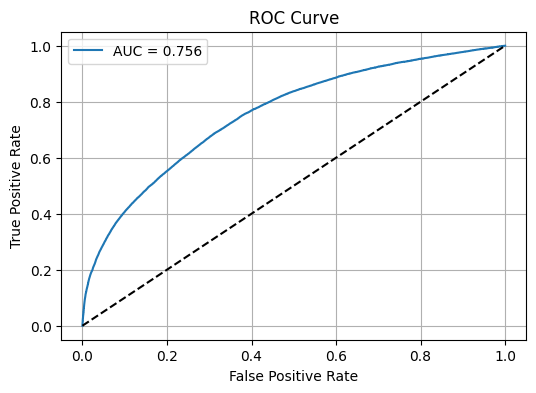

In [ ]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt
import torch.nn.functional as F
import numpy as np

def get_probs_and_true(model, loader):
    model.eval()
    all_probs = []
    all_labels = []
    with torch.no_grad():
        for x, y in loader:
            x = x.to(device)
            y = y.to(device)
            logits = model(x)
            probs = F.softmax(logits, dim=1)[:, 1]
            all_probs.extend(probs.cpu().numpy())
            all_labels.extend(y.cpu().numpy())
    return np.array(all_probs), np.array(all_labels)

probs, true_labels = get_probs_and_true(model, test_loader)

fpr, tpr, thresholds = roc_curve(true_labels, probs)
auc_score = auc(fpr, tpr)

print("AUC:", auc_score)

plt.figure(figsize=(6,4))
plt.plot(fpr, tpr, label=f"AUC = {auc_score:.3f}")
plt.plot([0,1], [0,1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.grid()
plt.show()


Confusion Matrix

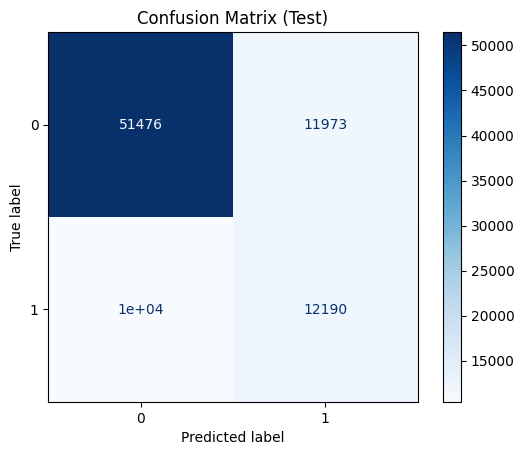

Confusion Matrix:
[[51476 11973]
 [10448 12190]]


In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# test_loader üzerinde tahmin al
model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for x, y in test_loader:
        x = x.to(device)
        y = y.to(device)
        logits = model(x)
        probs = F.softmax(logits, dim=1)
        preds = probs.argmax(dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(y.cpu().numpy())

cm = confusion_matrix(all_labels, all_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap="Blues")
plt.title("Confusion Matrix (Test)")
plt.show()

print("Confusion Matrix:")
print(cm)


Model Save / Load (Deployment)

In [ ]:
torch.save(model.state_dict(), "lstm_spoiler_model.pth")
print("Model saved as lstm_spoiler_model.pth")


Model saved as lstm_spoiler_model.pth


fazal yazım durumunda silmek için

In [ ]:
import pandas as pd

df = pd.read_csv("experiment_log_lstm.csv")

# 3. index'i sil
df = df.drop(index=1).reset_index(drop=True)

# tekrar kaydet
df.to_csv("experiment_log.csv", index=False)

df


,epoch,embedding_dim,hidden_dim,num_layers,bidirectional,lr,batch_size,max_len,test_loss,precision,recall,f1,accuracy,weight_decay,dropout
0,8,64,64,3,True,0.0010,128,100,0.728605,0.703455,0.659763,0.674966,0.659763,0.000001,0.3
1,20,64,64,2,True,0.0001,128,200,0.611014,0.718665,0.674504,0.689312,0.674504,0.000001,0.3


en son csvyi bilgiisyara kayıt etmek için


In [ ]:
from google.colab import files
files.download("experiment_log_lstm.csv")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>